In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import warnings


In [ ]:
# Suppress specific pandas warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# Set the specific Colab Drive path
dataset_dir = "ADD THE ADDRESS OF THE DATASET"

# Find all CSV files in the directory
csv_files = glob.glob(os.path.join(dataset_dir, '*.csv'))

# List to hold all processed dataframes
all_dataframes = []

In [ ]:
if not csv_files:
    print(f"No CSV files found in {dataset_dir}. Please check your Drive mount.")
else:
    print("--- STEP 1: Extracting files ---")
    print(f"Found {len(csv_files)} files to process.\n")

for file_path in csv_files:
    file_name = os.path.basename(file_path)

    # Skip if we encounter files from previous runs
    if file_name.startswith('dataset_') or file_name.startswith('ETL_') or file_name.startswith('heatmap_') or file_name.endswith('.png'):
        continue

    print(f"Processing: {file_name}")
    print("--- STEP 2: Cleaning data and removing noise ---")

    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading {file_name}: {e}")
        continue

    # ---------------------------------------------------------
    # Apply labels based on rules
    # ---------------------------------------------------------
    base_class = file_name.split('_p')[0]

    if base_class == "Entry_Exit":
        # Rule: rd_velocity_cm_s < 0 -> Entry, >= 0 -> Exit
        conditions = [
            (df['rd_velocity_cm_s'] < 0),
            (df['rd_velocity_cm_s'] >= 0)
        ]
        choices = ['ENTRY WALK', 'EXIT WALK']
        df['activity'] = np.select(conditions, choices, default='UNKNOWN')
    else:
        # Standardize other classes to UPPERCASE
        df['activity'] = base_class.upper()

    # ---------------------------------------------------------
    # Convert Datetime to Seconds (using 20Hz Sampling Rate)
    # ---------------------------------------------------------
    # Parse the datetime string into actual pandas datetime objects
    dt_parsed = pd.to_datetime(df['datetime'], errors='coerce', format='mixed')
    dt_parsed = dt_parsed.bfill().ffill()

    if not dt_parsed.isna().all():
        start_time_sec = dt_parsed.iloc[0].timestamp()
    else:
        start_time_sec = 0.0

    # 20 samples per second = 1 sample every 0.05 seconds.
    df['datetime_seconds'] = start_time_sec + (np.arange(len(df)) * 0.05)

    # Drop the original string column
    if 'datetime' in df.columns:
        df = df.drop(columns=['datetime'])

    # ---------------------------------------------------------
    # Noise Removal (Rolling Mean Filter) per file
    # ---------------------------------------------------------
    # Identify numeric columns for analysis
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # Exclude datetime_seconds from rolling mean so time doesn't get smoothed/distorted
    if 'datetime_seconds' in numeric_cols:
        numeric_cols.remove('datetime_seconds')

    # Window of 5 equates to 0.25 seconds of smoothing given a 20Hz sampling rate
    df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1, center=True).mean()

    # Fill edge NaNs created by rolling center
    df[numeric_cols] = df[numeric_cols].bfill().ffill()

    print(f"Finished processing {file_name}. Shape after noise removal: {df.shape}\n")
    all_dataframes.append(df)


--- STEP 1: Extracting files ---
Found 16 files to process.

Processing: Sitting_p1_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Sitting_p1_p10.csv. Shape after noise removal: (6599, 18)

Processing: Sitting_p3_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Sitting_p3_p10.csv. Shape after noise removal: (6598, 18)

Processing: Sitting_p2_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Sitting_p2_p10.csv. Shape after noise removal: (6000, 18)

Processing: Entry_Exit_p1_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Entry_Exit_p1_p10.csv. Shape after noise removal: (10200, 18)

Processing: Entry_Exit_p3_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Entry_Exit_p3_p10.csv. Shape after noise removal: (12056, 18)

Processing: Entry_Exit_p2_p10.csv
--- STEP 2: Cleaning data and removing noise ---
Finished processing Entry_Exit_p2_p10.csv. Shap

Combining all datasets...
Final combined dataset shape BEFORE dropping metadata: (103608, 18)
Dropped columns ['wifi', 'time_sync']. New shape BEFORE SMOTE: (103608, 16)

--- STEP 3: Applying SMOTE to handle Class Imbalance ---
Class distribution BEFORE balancing:
activity
SITTING       19197
EXIT WALK     18532
WALKING       17759
STANDING      17398
ENTRY WALK    15722
NO_PERSON     15000
Name: count, dtype: int64

Applying SMOTE with k_neighbors=5...

Class distribution AFTER balancing:
activity
SITTING       19197
EXIT WALK     19197
ENTRY WALK    19197
STANDING      19197
WALKING       19197
NO_PERSON     19197
Name: count, dtype: int64

Output after Step 3 (First 3 rows):
   rd_present  rd_distance_mm  rd_velocity_cm_s  rd_angle_deg    rd_x_mm     rd_y_mm  c4001_present  c4001_distance_m  c4001_velocity_m_s  c4001_energy  c4001_raw_targets  c4001_raw_distance_m  c4001_raw_velocity_m_s  c4001_raw_energy  datetime_seconds activity
0         1.0      996.966667               0.0    

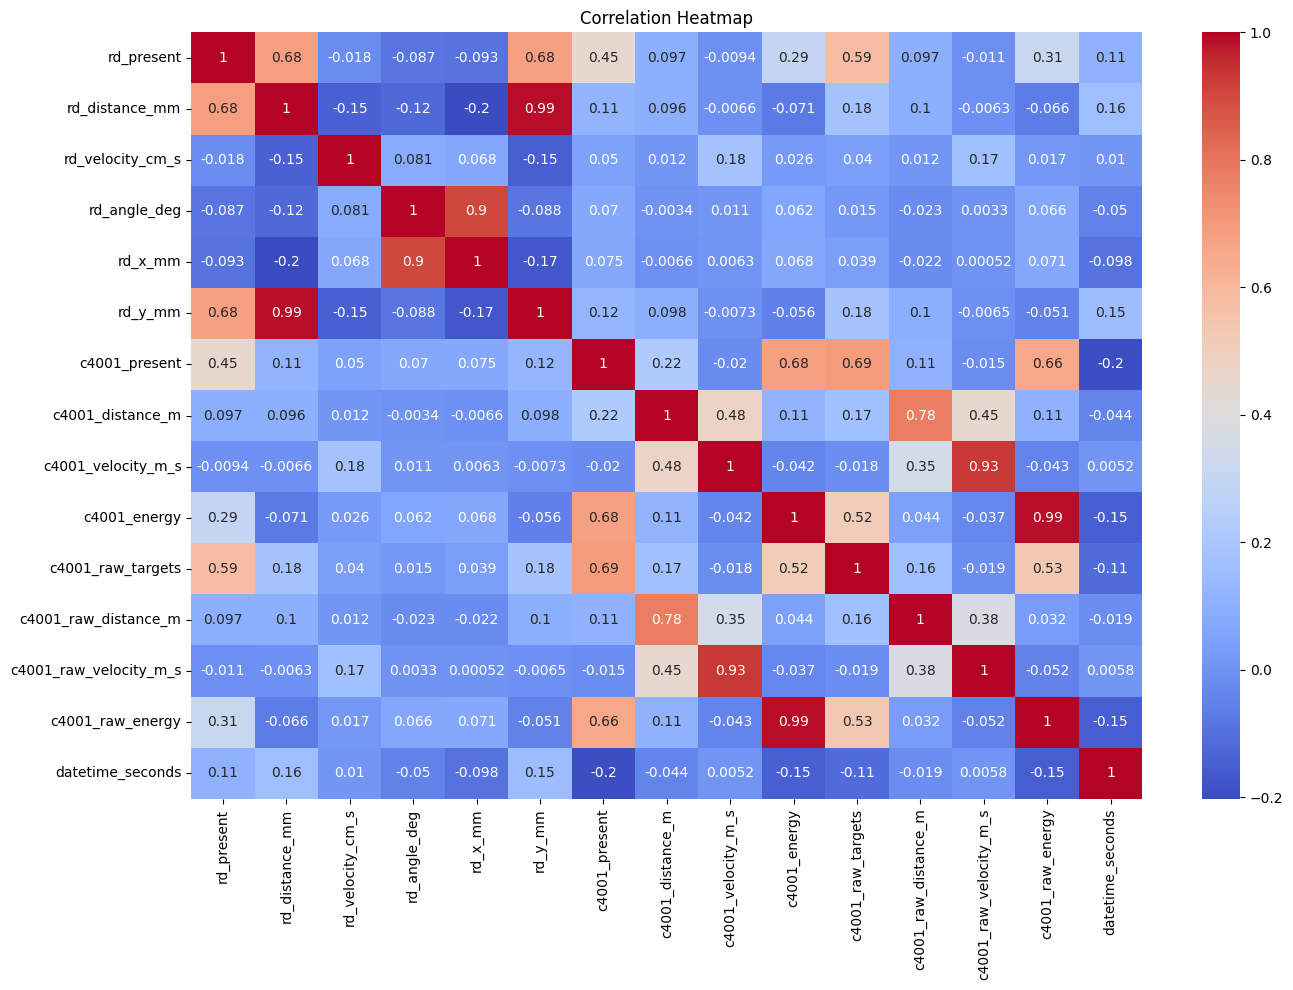

Saved correlation heatmap as 'correlation_heatmap.png'.

Combining highly correlated columns: 'rd_angle_deg' and 'rd_x_mm' (corr > 0.85)
Combining highly correlated columns: 'rd_distance_mm' and 'rd_y_mm' (corr > 0.85)
Combining highly correlated columns: 'c4001_velocity_m_s' and 'c4001_raw_velocity_m_s' (corr > 0.85)
Combining highly correlated columns: 'c4001_energy' and 'c4001_raw_energy' (corr > 0.85)

Dropped original columns: ['c4001_raw_velocity_m_s', 'rd_distance_mm', 'c4001_velocity_m_s', 'c4001_energy', 'rd_x_mm', 'rd_angle_deg', 'c4001_raw_energy', 'rd_y_mm']
Shape after combining correlated columns: (115182, 12)

Output after Step 4 (First 3 rows):
   rd_present  rd_velocity_cm_s  c4001_present  c4001_distance_m  c4001_raw_targets  c4001_raw_distance_m  datetime_seconds activity  combined_rd_angle_deg_rd_x_mm  combined_rd_distance_mm_rd_y_mm  combined_c4001_velocity_m_s_c4001_raw_velocity_m_s  combined_c4001_energy_c4001_raw_energy
0         1.0               0.0       0.33

In [ ]:
# ---------------------------------------------------------
# Merge into Master Dataframe
# ---------------------------------------------------------
if all_dataframes:
    print("Combining all datasets...")
    df_clean = pd.concat(all_dataframes, ignore_index=True)
    print(f"Final combined dataset shape BEFORE dropping metadata: {df_clean.shape}")

    # Drop irrelevant metadata columns before SMOTE
    cols_to_drop = ['wifi', 'time_sync', 'source_file']
    actual_cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]

    df_clean = df_clean.drop(columns=actual_cols_to_drop)
    print(f"Dropped columns {actual_cols_to_drop}. New shape BEFORE SMOTE: {df_clean.shape}\n")

    # ---------------------------------------------------------
    # STEP 3: Apply SMOTE
    # ---------------------------------------------------------
    print("--- STEP 3: Applying SMOTE to handle Class Imbalance ---")
    print("Class distribution BEFORE balancing:")
    print(df_clean['activity'].value_counts())

    # Separate features and target
    X = df_clean.drop(columns=['activity'])
    y = df_clean['activity']

    # Ensure no NaN values remain before SMOTE
    X = X.fillna(X.mean())

    print("\nApplying SMOTE with k_neighbors=5...\n")
    smote = SMOTE(k_neighbors=5, random_state=42)
    X_res, y_res = smote.fit_resample(X, y)

    # Recombine balanced data
    df_balanced = pd.concat([X_res, y_res], axis=1)

    print("Class distribution AFTER balancing:")
    print(df_balanced['activity'].value_counts())

    print("\nOutput after Step 3 (First 3 rows):")
    print(df_balanced.head(3).to_string())
    print("\n==================================================\n")

    # ---------------------------------------------------------
    # STEP 4: Heatmap and Correlated Columns
    # ---------------------------------------------------------
    print("--- STEP 4: Generating Heatmap and Combining Correlated Columns ---")

    # Plot Heatmap
    plt.figure(figsize=(14, 10))
    numeric_balanced = df_balanced.select_dtypes(include=[np.number])
    sns.heatmap(numeric_balanced.corr(), annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    heatmap_path = os.path.join(dataset_dir, 'correlation_heatmap.png')
    plt.savefig(heatmap_path)
    plt.show()  # Display in output
    print("Saved correlation heatmap as 'correlation_heatmap.png'.\n")

    # Combine highly correlated fields (> 0.85)
    cols_for_corr = [c for c in numeric_balanced.columns if c != 'datetime_seconds']
    corr_matrix = numeric_balanced[cols_for_corr].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    cols_to_drop_corr = set()

    for col in upper.columns:
        highly_correlated_with = upper.index[upper[col] > 0.85].tolist()
        for hc_col in highly_correlated_with:
            if col not in cols_to_drop_corr and hc_col not in cols_to_drop_corr:
                # ==============================================================
                # FIXED: Simple Average instead of Z-Score Standardization
                # This perfectly mirrors what the ESP32 code calculates natively!
                # ==============================================================
                new_col_name = f'combined_{hc_col}_{col}'
                df_balanced[new_col_name] = (df_balanced[col] + df_balanced[hc_col]) / 2.0

                cols_to_drop_corr.add(col)
                cols_to_drop_corr.add(hc_col)
                print(f"Combining highly correlated columns: '{hc_col}' and '{col}' (corr > 0.85)")

    dropped_list = list(cols_to_drop_corr)
    df_balanced.drop(columns=dropped_list, inplace=True)

    print(f"\nDropped original columns: {dropped_list}")
    print(f"Shape after combining correlated columns: {df_balanced.shape}\n")

    print("Output after Step 4 (First 3 rows):")
    print(df_balanced.head(3).to_string())
    print("\n==================================================\n")

    # ---------------------------------------------------------
    # STEP 5: Save Final Dataset
    # ---------------------------------------------------------
    final_output_path = os.path.join(dataset_dir, 'ETL_Balanced_Cleaned_Dataset_after_heatmap.csv')
    print(f"--- STEP 5: Saving transformed data to {final_output_path} ---")
    df_balanced.to_csv(final_output_path, index=False)
    print("ETL Pipeline completed successfully! ✅\n")

else:
    print("\nNo valid data was found to process.")